# Replicant — Convergence Benchmark Analysis

Loads `results.csv` from the repo root and produces thesis-ready figures in `figures/`.

**Generate results first:**
```sh
cargo run --bin orchestrator -- --trials 10 --output csv \
  scenarios/full-mesh-n{2,3,5,10}.toml \
  scenarios/partition-heal-n{4,6,8}.toml \
  2>/dev/null > results.csv
```

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

REPO = Path("..")  # notebook lives in analysis/
CSV     = REPO / "results.csv"
PARQUET = REPO / "results.parquet"
FIGS    = Path("figures")
FIGS.mkdir(exist_ok=True)

## Load data

On first run the CSV is parsed and cached as Parquet (preserves dtypes, loads faster on reruns).

In [2]:
if PARQUET.exists():
    df = pd.read_parquet(PARQUET)
else:
    df = pd.read_csv(CSV)
    df.to_parquet(PARQUET)

trials  = df[df.row_type == "trial"].copy()
summary = df[df.row_type == "summary"].copy()
# In summary rows the `trial` column holds the trial count, not a trial number.
summary = summary.rename(columns={"trial": "n_trials"})

print(f"{len(trials)} trial records, {trials.scenario.nunique()} scenarios, "
      f"{trials.groupby('scenario').size().iloc[0]} trials each")
summary[["scenario", "n_trials", "node_count", "op_count", "mean_ms", "p50_ms", "p95_ms"]]

70 trial records, 7 scenarios, 10 trials each


,scenario,n_trials,node_count,op_count,mean_ms,p50_ms,p95_ms
10,full-mesh-n2,10,2,2,1.8,2.0,3.0
21,full-mesh-n3,10,3,6,1.1,1.0,2.0
32,full-mesh-n5,10,5,10,1.9,2.0,2.0
43,full-mesh-n10,10,10,20,3.0,3.0,3.0
54,partition-heal-n4,10,4,8,56.5,56.0,58.0
65,partition-heal-n6,10,6,12,58.7,59.0,60.0
76,partition-heal-n8,10,8,16,62.5,62.0,63.0


## Full-mesh: convergence vs node count

Measures time from last write to all-nodes fingerprint agreement.
Shaded band shows p50–p95 range across trials.

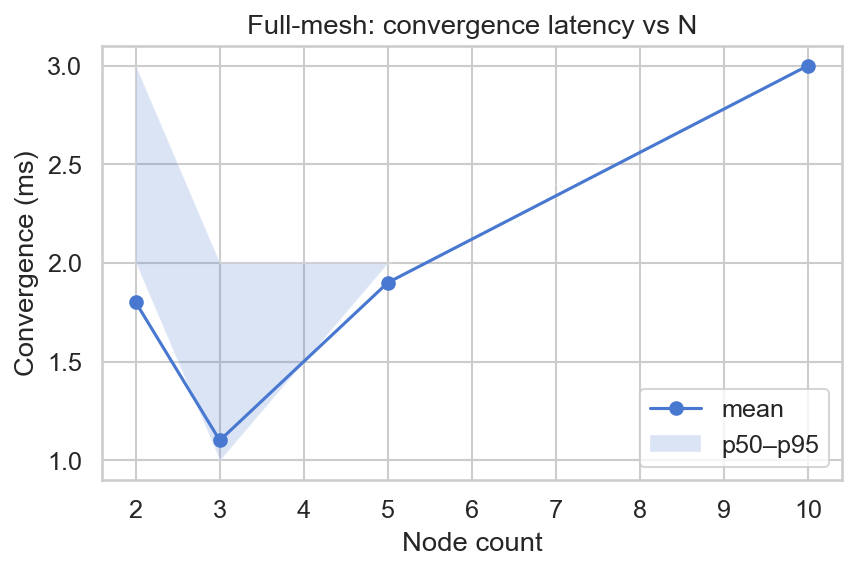

In [3]:
mesh = summary[summary.scenario.str.startswith("full-mesh")].sort_values("node_count")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mesh.node_count, mesh.mean_ms, "o-", label="mean")
ax.fill_between(mesh.node_count, mesh.p50_ms, mesh.p95_ms, alpha=0.2, label="p50–p95")
ax.set_xlabel("Node count")
ax.set_ylabel("Convergence (ms)")
ax.set_title("Full-mesh: convergence latency vs N")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "full_mesh_scaling.pdf")
plt.show()

## Partition-heal: convergence vs partition depth

Measures time from heal trigger (cross-group edges added) to global convergence.

> **Note:** The current runner sleeps 50 ms after each `ConnectPeer` call to let the
> Automerge sync handshake settle before reads begin. This dominates the heal numbers
> (~55–63 ms). Net CRDT merge cost is the remainder above 50 ms. Step 9 should
> instrument this more precisely (remove the fixed sleep, poll for sync readiness).

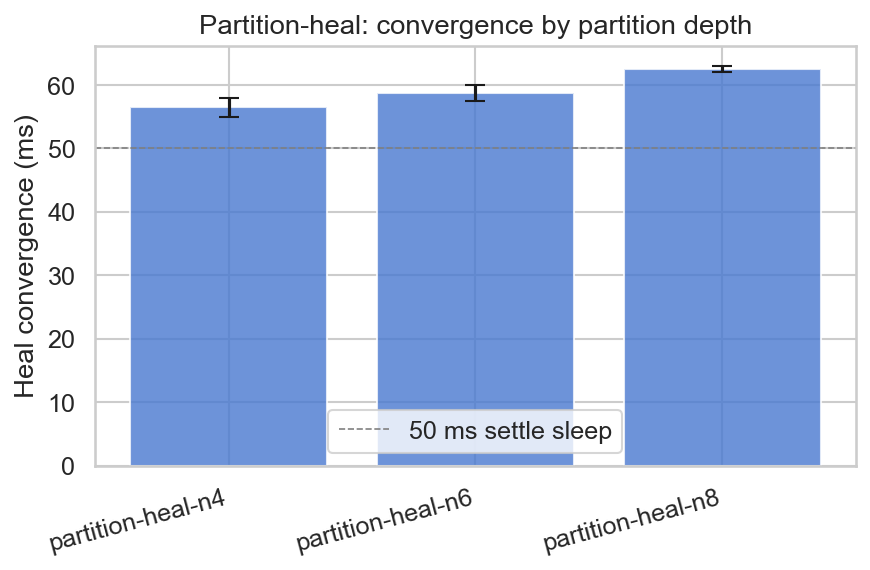

In [4]:
heal = summary[summary.scenario.str.startswith("partition")].sort_values("node_count")

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(heal))
ax.bar(x, heal.mean_ms, yerr=heal.p95_ms - heal.mean_ms, capsize=5, alpha=0.8)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50 ms settle sleep")
ax.set_xticks(list(x))
ax.set_xticklabels(heal.scenario, rotation=15, ha="right")
ax.set_ylabel("Heal convergence (ms)")
ax.set_title("Partition-heal: convergence by partition depth")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "partition_heal.pdf")
plt.show()

## Raw distributions (box plots)

Shows the full trial distribution rather than summary statistics.
More honest for small N — outliers are visible.

/var/folders/hs/cl_jqwb10y1c8rj025dblqww0000gn/T/ipykernel_31659/4262755604.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


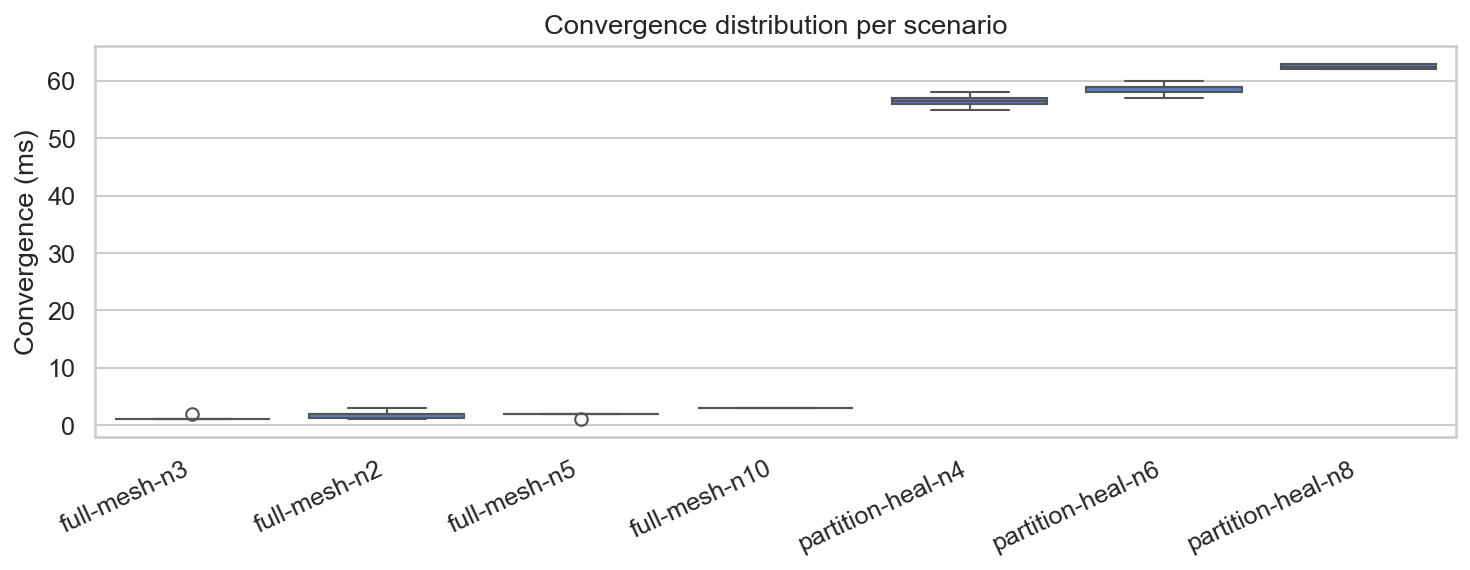

In [5]:
order = (
    trials.groupby("scenario")["convergence_ms"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=trials, x="scenario", y="convergence_ms", order=order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_xlabel(None)
ax.set_ylabel("Convergence (ms)")
ax.set_title("Convergence distribution per scenario")
fig.tight_layout()
fig.savefig(FIGS / "boxplot.pdf")
plt.show()

## Summary table

Formatted for copy-paste into the thesis evaluation section.

In [6]:
table = summary[["scenario", "node_count", "n_trials", "mean_ms", "p50_ms", "p95_ms"]].copy()
table.columns = ["Scenario", "Nodes", "Trials", "Mean (ms)", "p50 (ms)", "p95 (ms)"]
table = table.set_index("Scenario")
table.style.format({
    "Mean (ms)": "{:.1f}",
    "p50 (ms)":  "{:.1f}",
    "p95 (ms)":  "{:.1f}",
})

,Nodes,Trials,Mean (ms),p50 (ms),p95 (ms)
Scenario,,,,,
full-mesh-n2,2,10,1.8,2.0,3.0
full-mesh-n3,3,10,1.1,1.0,2.0
full-mesh-n5,5,10,1.9,2.0,2.0
full-mesh-n10,10,10,3.0,3.0,3.0
partition-heal-n4,4,10,56.5,56.0,58.0
partition-heal-n6,6,10,58.7,59.0,60.0
partition-heal-n8,8,10,62.5,62.0,63.0
